In [32]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk("Iris.csv"):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [33]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [34]:
df = df.iloc[:,1:]

In [35]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [36]:
from sklearn.preprocessing import LabelEncoder

In [37]:
encoder = LabelEncoder()

In [38]:

df['Species'] = encoder.fit_transform(df['Species'])

In [40]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [41]:

df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [42]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

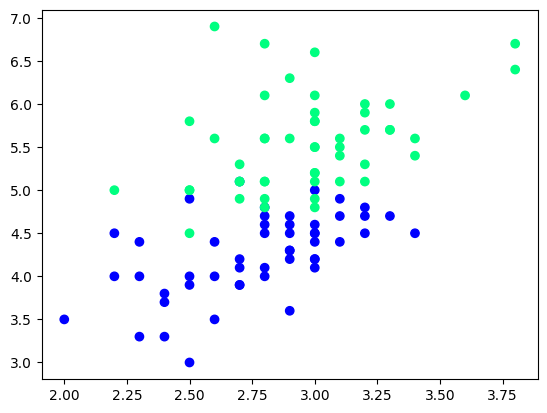

In [45]:

plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [47]:

df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
88,3.0,4.1,1
50,3.2,4.7,1
91,3.0,4.6,1
53,2.3,4.0,1
81,2.4,3.7,1
107,2.9,6.3,2
109,3.6,6.1,2
85,3.4,4.5,1
77,3.0,5.0,1
79,2.6,3.5,1


In [48]:

# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [50]:
df_train

,SepalWidthCm,PetalLengthCm,Species
68,2.2,4.5,1
78,2.9,4.5,1
122,2.8,6.7,2
75,3.0,4.4,1
148,3.4,5.4,2
95,3.0,4.2,1
90,2.6,4.4,1
60,2.0,3.5,1
120,3.2,5.7,2
133,2.8,5.1,2


In [51]:
df_val

,SepalWidthCm,PetalLengthCm,Species
69,2.5,3.9,1
130,2.8,6.1,2
52,3.1,4.9,1
71,2.8,4.0,1
70,3.2,4.8,1


In [52]:
df_test

,SepalWidthCm,PetalLengthCm,Species
107,2.9,6.3,2
128,2.8,5.6,2
105,3.0,6.6,2
139,3.1,5.4,2
147,3.0,5.2,2


In [53]:

X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [54]:
y_test

array([1, 2, 1, 1, 1])

# Case 1 - Bagging

In [55]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
148,3.4,5.4,2
95,3.0,4.2,1
148,3.4,5.4,2
95,3.0,4.2,1
95,3.0,4.2,1
68,2.2,4.5,1
148,3.4,5.4,2
60,2.0,3.5,1


In [56]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [59]:
dt_bag1 = DecisionTreeClassifier()

NotFittedError: This DecisionTreeClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.